# **02 · 개념→변수 정렬 — 해마다 흩어진 문항을 어떻게 같은 자(尺)로 묶나**

### **"7개년(2019~2025) 설문은 같은 개념을 해마다 다른 문항번호로 묻는다 — 신뢰 '공정'은 Q77→Q78→Q69→Q85로 번호가 리셋되고, 매체 이용은 종이신문만 freq·days·bin 세 형식을 오간다. 변수명으로는 못 잇는다. 개념(형용사·매체)으로 정렬해야 7개년이 한 패널이 된다. 신뢰축은 핵심3로 정렬되어 reflective→연도 비교가 가능하고, 다양성축은 8매체 고정풀로 구성을 고정해 formative→방향성만 본다 — 이 정렬의 정합성을 패널로 입증한다."**

> KPF 「언론 통계 분석·활용 경진대회」 · 분석 단위 = **연도(2019~2025) × 응답자(N=90,996)** · 산출 = 신뢰·다양성 두 축의 **개념→변수 크로스워크 검증** + 최종 매핑표(SSOT)

> 📍 **파이프라인 위치**: 5단계 표준 흐름 中 **② 데이터 전처리(개념 정렬 확정)** · CRISP-DM **P3(Data Preparation)** · 선행 [`10-data-understanding`](10-data-understanding.ipynb)(메타·crosswalk 가용성) · [전체 지도](README.md)

> SSOT 모듈: [`src/harmonize.py`](../src/harmonize.py)(`CRED_BATTERY`·`USE_BATTERY`·`SRC`) · [`src/health_index_panel.py`](../src/health_index_panel.py)(thin 어댑터). 본 노트북은 그 매핑을 **검증·문서화**한다(재구현 없음).

## **연구 질문 (이 노트북이 답하는 것)**

> **Q1.** 신뢰 개념은 7개년에 어떻게 흩어져 있고, 어떤 지표만 **공통 핵심**으로 묶이는가 — 문항번호로 직결되는가, 형용사(공정·전문·정확)로 정렬해야 하는가?
> **Q2.** 그 핵심3 지표는 **같은 잠재요인을 반영(reflective)** 하는가 — pooled 상관·신뢰도가 받쳐 연도 비교를 허용하는가? `press_free`·`media_influence`는 왜 배제되는가?
> **Q3.** 다양성 8매체 고정풀은 해마다 **다른 문항 형식**(freq·days·bin·or)으로 오는데, 어떻게 하나의 *이용여부*로 정렬되나 — 왜 formative라 방향성만 보는가?
> **Q4.** 이 개념→변수 정렬이 **지수**(신뢰·다양성·NCHI)로 어떻게 이어지나 — 두 축의 해석 규칙(연도 비교 / 방향성)은 왜 갈리나?

## **목차**

| § | 내용 | 핵심 질문 | 산출 |
|:--:|------|-----------|------|
| 1 | 신뢰 개념→변수 크로스워크 (+ DB①) | 무엇이 공통 핵심3인가 | CRED 배터리 7개년 가용성 |
| 2 | 신뢰 정렬 정합성 | 핵심3은 한 요인을 반영하나 | pooled 상관·α·연도별 α |
| 3 | 다양성 8매체 정렬 (+ DB②) | 다른 형식을 어떻게 묶나 | 디스크립터 지도·고정풀 |
| 4 | 정렬→지수 | 두 축 규칙은 왜 갈리나 | 신뢰(비교)·다양성(방향) 지수 |
| 5 | 최종 변수 매핑표 | SSOT 확정 | 개념→7개년 변수→처리 |
| 6 | 종합 | 정렬→후속 매핑 | 21·22·03 근거 |

> 🔄 **v1 → v2 변경 이력**: v1(`02-variable-mapping` 단년)은 **2025 한 해**의 코드북↔지수 매핑을 확정했다(22문항 `TRUST_CORE` α·고유값·요인적재, `NEWS_DAYS` 12유형 Richness). v2는 관점을 **7개년 패널**로 올린다 — ① 단년 22문항 신뢰 코어 → 7개년 **공통 핵심3**(`CRED_FACTOR_CORE3`: 공정·전문·정확)로 축소·정렬, ② 단년 12유형 Richness → 7개년 **8매체 고정풀**(`FIXED_POOL8`)로 구성 고정, ③ 검증 대상이 *2025 컬럼 선택*에서 *연도 간 개념 정렬의 정합성*으로 이동. 단년 노트북은 이력 보존을 위해 그대로 두고, 본 노트북은 `harmonize`/`health_index_panel`을 import해 패널 매핑만 입증한다.

In [1]:
# === 02 · 개념->변수 정렬 — 셋업 & 패널 적재 ===
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
from matplotlib.colors import ListedColormap

def _kfont():
    """한글 폰트 우선 적용. 마이너스는 ASCII '-'(U+2212 깨짐 방지)."""
    for nm in ["Malgun Gothic", "맑은 고딕", "NanumGothic", "Gulim"]:
        try:
            font_manager.findfont(nm, fallback_to_default=False)
            plt.rcParams["font.family"] = nm
            break
        except Exception:
            continue
    plt.rcParams["axes.unicode_minus"] = False
_kfont()

def find_root() -> Path:
    p = Path.cwd().resolve()
    for cand in [p, *p.parents]:
        if (cand / "src/health_index_panel.py").exists():
            return cand
    raise FileNotFoundError("src/health_index_panel.py 를 찾지 못했습니다")

ROOT = find_root()
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))
import harmonize as hz                # 패널 스펙(SSOT): CRED_BATTERY·USE_BATTERY·SRC·핵심3·고정풀8
import health_index_panel as hip      # thin 어댑터(연도 지수)
import news_health_features as nf     # 공통 수학(cronbach_alpha 등) — 재구현 금지

# ⚠️ 패널 parquet은 gitignore → 없으면 먼저 `python src/harmonize.py`로 재생성.
panel = hip.load_panel()
YEARS = hz.YEARS
N = len(panel)
CORE3 = hz.CRED_FACTOR_CORE3
POOL8 = hz.FIXED_POOL8
print(f"패널 적재: {N:,}행 × {panel.shape[1]}변수  ·  연도 {YEARS}")
print(f"신뢰 핵심3 = {CORE3}")
print(f"다양성 고정풀8 = {POOL8}")

패널 적재: 90,996행 × 45변수  ·  연도 [2019, 2020, 2021, 2022, 2023, 2024, 2025]
신뢰 핵심3 = ['cred_fair', 'cred_professional', 'cred_accurate']
다양성 고정풀8 = ['use_paper', 'use_magazine', 'use_tv', 'use_radio', 'use_internet', 'use_messenger', 'use_sns', 'use_video']


## 1. 신뢰 개념→변수 크로스워크 — 무엇이 7개년 공통 '핵심3'인가

언론 신뢰성(credibility)은 "우리나라 언론은 ~하다" 5점 동의 배터리로 측정된다. 문제는 **문항번호가 해마다 리셋**된다는 것 — '공정하다'는 2019 `Q77_1`, 2020·2021 `Q78_1`, 2022 `Q69_1`, 2023·2024 `Q77_1`, 2025 `Q85_1`이다. 변수명으로는 7개년을 못 잇는다. **형용사(개념)** 로 정렬해야 한다. 게다가 배터리 구성도 변한다 — `cred_trustworthy`(신뢰할 수 있다)는 2023부터 사라지고, `media_influence`(영향력)는 2021부터 등장한다. 7개년 **전부** 존재하면서 같은 valence(긍정 평가)인 지표만이 종단 신뢰요인의 자격을 갖는다.

In [2]:
# 신뢰성(credibility) 배터리 — 형용사(개념) x 7개년 src 문항번호 (harmonize.CRED_BATTERY)
rows = []
for ind, ymap in hz.CRED_BATTERY.items():
    mark = "[핵심3]" if ind in CORE3 else ""
    rows.append([ind, mark] + [ymap[y] or "-" for y in YEARS])
cw = pd.DataFrame(rows, columns=["indicator", "role"] + [str(y) for y in YEARS])
print("[신뢰성 배터리 크로스워크 — 문항번호는 해마다 리셋, 형용사로 정렬]")
print(cw.to_string(index=False))

# 7개년 가용성: 각 지표가 몇 개년에 존재하나 + 핵심3 완전케이스 N
avail = {ind: sum(ymap[y] is not None for y in YEARS) for ind, ymap in hz.CRED_BATTERY.items()}
cc = panel[CORE3].notna().all(axis=1).groupby(panel["year"]).sum()
print("\n[지표별 존재 연도수(7=전개년)]:", {k: int(v) for k, v in avail.items()})
print("[핵심3 완전케이스 N(연도별)]:", {int(y): int(cc[y]) for y in YEARS})
print("\n-> 7개년 전부(존재=7)이면서 긍정 valence = 공정/전문/정확 = 핵심3.")
print("   cred_trustworthy(4개년)·media_influence(5개년)는 결측연도 발생 -> 종단 주모형 배제.")

[신뢰성 배터리 크로스워크 — 문항번호는 해마다 리셋, 형용사로 정렬]
        indicator  role  2019  2020  2021  2022  2023  2024  2025
        cred_fair [핵심3] Q77_1 Q78_1 Q78_1 Q69_1 Q77_1 Q77_1 Q85_1
cred_professional [핵심3] Q77_2 Q78_2 Q78_2 Q69_2 Q77_2 Q77_2 Q85_2
    cred_accurate [핵심3] Q77_3 Q78_3 Q78_3 Q69_3 Q77_3 Q77_3 Q85_3
 cred_trustworthy       Q77_4 Q78_4 Q78_4 Q69_4     -     -     -
       press_free       Q77_5 Q78_5 Q78_5 Q69_5 Q77_4 Q77_4 Q85_4
  media_influence           -     - Q78_6 Q69_6 Q77_5 Q77_5 Q85_5

[지표별 존재 연도수(7=전개년)]: {'cred_fair': 7, 'cred_professional': 7, 'cred_accurate': 7, 'cred_trustworthy': 4, 'press_free': 7, 'media_influence': 5}
[핵심3 완전케이스 N(연도별)]: {2019: 5040, 2020: 5010, 2021: 5010, 2022: 58936, 2023: 5000, 2024: 6000, 2025: 6000}

-> 7개년 전부(존재=7)이면서 긍정 valence = 공정/전문/정확 = 핵심3.
   cred_trustworthy(4개년)·media_influence(5개년)는 결측연도 발생 -> 종단 주모형 배제.


**[시각화 ①] 신뢰성 배터리 가용성 지도** — 형용사(행) × 연도(열). 핵심3(공정·전문·정확)만 7칸이 모두 채워지고, trustworthy(4개년)·influence(5개년)는 중간이 비어 있다 — '형용사 정렬'이 아니면 이 지도 자체를 그릴 수 없다.

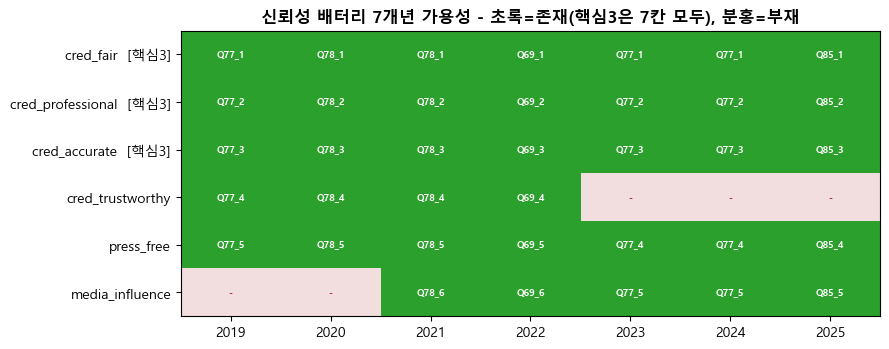

In [3]:
# [시각화 ①] 신뢰성 배터리 7개년 가용성 지도 — 핵심3만 7칸 모두 채워짐
present = np.array([[1 if hz.CRED_BATTERY[ind][y] else 0 for y in YEARS]
                    for ind in hz.CRED_BATTERY])
inds = list(hz.CRED_BATTERY)
fig, ax = plt.subplots(figsize=(9, 3.6))
ax.imshow(present, cmap=ListedColormap(["#f2dede", "#2ca02c"]), aspect="auto", vmin=0, vmax=1)
ax.set_xticks(range(len(YEARS))); ax.set_xticklabels([str(y) for y in YEARS])
ax.set_yticks(range(len(inds)))
ax.set_yticklabels([f"{i}  [핵심3]" if i in CORE3 else i for i in inds])
for r in range(len(inds)):
    for c in range(len(YEARS)):
        v = hz.CRED_BATTERY[inds[r]][YEARS[c]]
        ax.text(c, r, v or "-", ha="center", va="center", fontsize=7,
                color="white" if present[r, c] else "#a33", weight="bold")
ax.set_title("신뢰성 배터리 7개년 가용성 - 초록=존재(핵심3은 7칸 모두), 분홍=부재", weight="bold")
plt.tight_layout(); plt.show()

> #### 🟦 Decision Box ① — 신뢰 종단요인 = credibility **핵심3**(공정·전문·정확)
>
> **결정**: 7개년 신뢰축은 22문항 단년 코어가 아니라 **공정·전문·정확 3지표**(`CRED_FACTOR_CORE3`)로 정렬한다. `cred_trustworthy`는 민감도(2019~2022)로만, `press_free`·`media_influence`는 배제한다.
>
> **근거**: 종단 비교의 전제는 *모든 연도에 같은 지표가 존재*하는 것이다. 공정·전문·정확만 7개년 전부 존재한다(완전케이스 5,000~58,936). `cred_trustworthy`는 2023부터 부재(4개년뿐), `media_influence`는 2021부터 등장(5개년)이라 종단 주모형에 넣으면 결측연도가 추세를 끊는다. `press_free`(언론자유)는 *평가 대상*이 아니라 *제도 상태*라 별개 구성개념(§2에서 상관으로 확인).
>
> **대안 기각**: ① 단년 22문항 코어 유지 → 2025에만 있는 문항 多, 7개년 비교 불가. ② 가용 지표 전부 합산 → 결측연도가 지표마다 달라 '같은 자' 위반. 핵심3 고정이 종단 등가의 최소 충분집합.

#### **[발견 ①] 신뢰는 '형용사로 정렬'해야 이어지고, 7개년 공통은 공정·전문·정확 셋뿐이다**

신뢰성 배터리는 문항번호가 `Q77→Q78→Q69→Q77→Q85`로 해마다 리셋되어 **변수명 직결이 원천 불가**하다 — 개념(형용사)을 키로 삼아야 7개년이 정렬된다(`harmonize.CRED_BATTERY`가 그 매핑의 SSOT). 그리고 배터리 구성 자체가 유동적이라, 7개년 전부 존재하면서 같은 긍정 valence인 지표는 **공정·전문·정확 3개**뿐이다(완전케이스 2019 5,040 … 2025 6,000). `cred_trustworthy`는 4개년, `media_influence`는 5개년에 그쳐 종단 주모형에서 빠진다(DB①). 즉 7개년 신뢰축의 **자격 집합은 핵심3로 확정**된다.

→ **① 신뢰 크로스워크 — 완료(핵심3 확정). 다음은 그 셋이 정말 한 요인을 반영하는지.**

## 2. 신뢰 정렬 정합성 — 핵심3은 같은 잠재요인을 반영(reflective)하나

핵심3를 한 신뢰점수로 합성하려면, 세 지표가 **공통 잠재요인의 반영(reflective)** 이어야 한다 — 즉 서로 충분히 상관하고 내적 일관성(α)이 높아야 한다. pooled(7개년 통합) 상관·α로 이를 확인하고, 연도별 α로 *시간에 따라도 일관*한지 본다. 동시에 배제 지표(`press_free`·`media_influence`)가 핵심3와 얼마나 떨어져 있는지를 상관으로 확인해 DB①의 배제를 정당화한다.

In [4]:
# pooled 상관(핵심3 + 배제 후보) — 핵심3 블록이 서로 높고, 배제군과는 약함
inds5 = CORE3 + ["press_free", "media_influence"]
sub = panel[inds5].apply(pd.to_numeric, errors="coerce")
corr = sub.corr()
print("[pooled 지표 간 상관 — 핵심3 블록(좌상 3x3)이 응집]")
print(corr.round(3).to_string())

# pooled Cronbach alpha (공통 수학 재사용)
a_core3 = nf.cronbach_alpha(panel[CORE3].apply(pd.to_numeric, errors="coerce"))
a_plus  = nf.cronbach_alpha(panel[CORE3 + ["cred_trustworthy"]].apply(pd.to_numeric, errors="coerce"))
a_wpf   = nf.cronbach_alpha(panel[CORE3 + ["press_free"]].apply(pd.to_numeric, errors="coerce"))
print(f"\n[pooled Cronbach a] 핵심3={a_core3:.3f}  핵심3+신뢰할수있다={a_plus:.3f}  핵심3+언론자유={a_wpf:.3f}")
print(f"  -> press_free 추가해도 a 불변({a_wpf:.3f}=핵심3) = 신뢰요인에 기여 없음(별개 차원).")

# 핵심3 평균 vs 배제군 상관(별개 차원 정량)
c3m = sub[CORE3].mean(axis=1)
for col in ["press_free", "media_influence"]:
    m = c3m.notna() & sub[col].notna()
    r = float(np.corrcoef(c3m[m], sub[col][m])[0, 1])
    print(f"  corr(핵심3평균, {col}) = {r:+.3f}  (관련되나 구분 -> 통제/배제)")

[pooled 지표 간 상관 — 핵심3 블록(좌상 3x3)이 응집]
                   cred_fair  cred_professional  cred_accurate  press_free  media_influence
cred_fair              1.000              0.550          0.636       0.414            0.355
cred_professional      0.550              1.000          0.553       0.462            0.479
cred_accurate          0.636              0.553          1.000       0.428            0.396
press_free             0.414              0.462          0.428       1.000            0.541
media_influence        0.355              0.479          0.396       0.541            1.000

[pooled Cronbach a] 핵심3=0.805  핵심3+신뢰할수있다=0.863  핵심3+언론자유=0.805
  -> press_free 추가해도 a 불변(0.805=핵심3) = 신뢰요인에 기여 없음(별개 차원).
  corr(핵심3평균, press_free) = +0.513  (관련되나 구분 -> 통제/배제)
  corr(핵심3평균, media_influence) = +0.484  (관련되나 구분 -> 통제/배제)


In [5]:
# 연도별 Cronbach alpha — 시간에 따라도 내적일관성 유지되나
ay = {}
for y in YEARS:
    X = panel.loc[panel.year == y, CORE3].apply(pd.to_numeric, errors="coerce")
    ay[y] = nf.cronbach_alpha(X)
print("[연도별 핵심3 Cronbach a]")
for y in YEARS:
    print(f"  {y}: a={ay[y]:.3f}")
print(f"\n  범위 [{min(ay.values()):.3f}, {max(ay.values()):.3f}] — 2025({ay[2025]:.3f})가 최저(여전히 >0.70 수용).")
print("  -> 내적 일관성은 7개년 유지. 단 a는 '동일 척도'의 필요조건일 뿐 -> 측정불변은 21·22 MGCFA에서 검정.")

[연도별 핵심3 Cronbach a]
  2019: a=0.782
  2020: a=0.809
  2021: a=0.801
  2022: a=0.816
  2023: a=0.790
  2024: a=0.781
  2025: a=0.701

  범위 [0.701, 0.816] — 2025(0.701)가 최저(여전히 >0.70 수용).
  -> 내적 일관성은 7개년 유지. 단 a는 '동일 척도'의 필요조건일 뿐 -> 측정불변은 21·22 MGCFA에서 검정.


**[시각화 ②] 핵심3 응집** — (좌) pooled 상관 히트맵: 핵심3 블록(0.55~0.64)이 배제 후보와의 상관보다 뚜렷이 높다. (우) 연도별 Cronbach α(0.70~0.82): 내적일관성이 시간에 대해 유지된다 — reflective 자격의 두 근거.

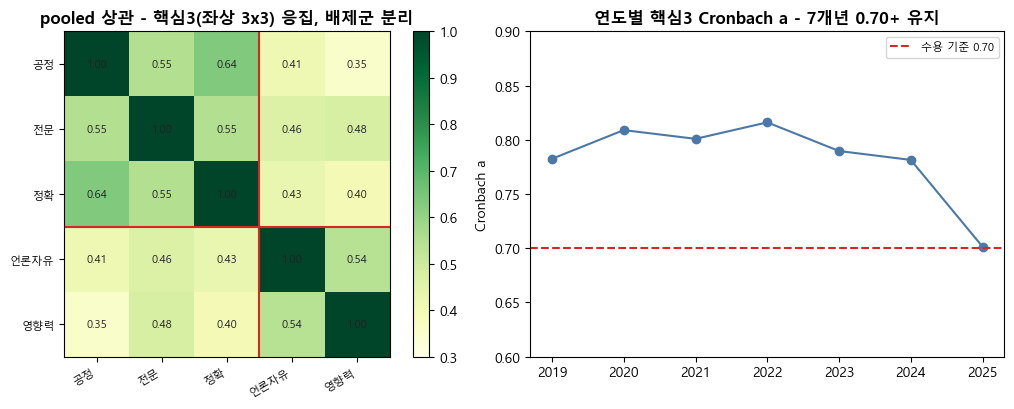

In [6]:
# [시각화 ②] (좌) 지표 상관 히트맵 — 핵심3 응집 (우) 연도별 alpha
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

im = axes[0].imshow(corr.values, cmap="YlGn", vmin=0.3, vmax=1.0)
axes[0].set_xticks(range(len(inds5))); axes[0].set_yticks(range(len(inds5)))
short = ["공정", "전문", "정확", "언론자유", "영향력"]
axes[0].set_xticklabels(short, rotation=30, ha="right", fontsize=8)
axes[0].set_yticklabels(short, fontsize=8)
for i in range(len(inds5)):
    for j in range(len(inds5)):
        axes[0].text(j, i, f"{corr.values[i, j]:.2f}", ha="center", va="center",
                     fontsize=8, color="#222")
axes[0].axhline(2.5, color="#d62728", lw=1.5); axes[0].axvline(2.5, color="#d62728", lw=1.5)
axes[0].set_title("pooled 상관 - 핵심3(좌상 3x3) 응집, 배제군 분리", weight="bold")
fig.colorbar(im, ax=axes[0], fraction=0.046)

axes[1].plot([str(y) for y in YEARS], [ay[y] for y in YEARS], "o-", color="#4C78A8")
axes[1].axhline(0.70, ls="--", color="#d62728", label="수용 기준 0.70")
axes[1].set_ylim(0.6, 0.9)
axes[1].set_title("연도별 핵심3 Cronbach a - 7개년 0.70+ 유지", weight="bold")
axes[1].set_ylabel("Cronbach a"); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

#### **[발견 ②] 핵심3는 한 요인을 반영하는 reflective 집합이고, 언론자유·영향력은 다른 차원이다**

핵심3 pooled 상관은 0.55~0.64(공정~정확 0.64 최고)로 서로 응집하고, pooled α=0.805로 내적 일관성이 높다 — **세 지표가 공통 신뢰요인을 반영(reflective)** 한다는 직접 증거다. 반면 `press_free`를 더해도 α는 0.805로 **불변**(기여 없음), 핵심3 평균과의 상관도 +0.51(언론자유)·+0.48(영향력)로 *관련되나 구분*된다 — 언론자유는 *평가*가 아닌 *제도 상태*, 영향력은 valence가 모호해 DB①의 배제가 정당하다. 연도별 α도 0.70~0.82로 7개년 안정적이며 2025(0.701)가 최저다. 다만 α는 "같은 자"의 **필요조건일 뿐 충분조건이 아니다** — 연도 간 *측정불변*은 21·22 MGCFA에서 별도로 검정한다. 이 reflective 성격이 신뢰축의 **연도 비교를 허용**하는 근거다.

→ **② 신뢰 정렬 정합성 — 완료(reflective 입증). 다음은 다양성의 정렬.**

## 3. 다양성 8매체 정렬 — 다른 문항 형식을 어떻게 하나의 '이용여부'로 묶나

다양성은 *몇 종의 매체로 뉴스를 보나*(Richness)로 잡는다. 그런데 매체 이용은 연도마다 **문항 형식이 제각각**이다 — 종이신문은 2019 열독빈도(`freq`), 2020·2021 이용일수(`days`), 2022부터 이용여부(`bin`)로 묻고, 인터넷은 7개년 모두 다중응답·기기분리를 OR로 통합(`or`)해야 한다. `harmonize.USE_BATTERY`는 이 형식 차이를 디스크립터로 흡수해 **모두 '이용여부(>0)' 이진**으로 정렬한다. 그 결과가 7개년 공통 **8매체 고정풀**(`FIXED_POOL8`)이며, 합이 `richness_fixed8`(0~8)이다. ⚠️ 다양성은 매체 목록이 지수를 *구성(formative)* 하므로, 여기서는 *매핑이 연도마다 합리적으로 해석되는지*(정렬 검증)만 보고 **절대수준의 연도 비교는 하지 않는다**(06 §결과 R4).

In [7]:
# 8매체 x 7개년 디스크립터 형식 (harmonize.USE_BATTERY) — 형식이 달라도 모두 이용여부로 정렬
rows = []
for med, ymap in hz.USE_BATTERY.items():
    rows.append([med] + [ymap[y][0] for y in YEARS])
dmap = pd.DataFrame(rows, columns=["medium"] + [str(y) for y in YEARS])
print("[8매체 디스크립터 형식 — freq/days/bin/or]")
print(dmap.to_string(index=False))

from collections import Counter
kinds = Counter(ymap[y][0] for ymap in hz.USE_BATTERY.values() for y in YEARS)
print(f"\n[형식 분포 56칸] {dict(kinds)}  (bin=이용여부 직접, or=다중응답 통합, days/freq=일수/빈도->이진화)")
print("[신설 디지털매체(고정풀 밖, 보조)]:",
      {m: [y for y in YEARS if y in d] for m, d in hz.USE_NEW_MEDIA.items()})
print(f"-> 56칸 모두 이용여부(>0)로 정렬 -> richness_fixed8(0~8). 신설(숏폼/OTT/AI)은 부재연도 多 -> richness_incl 보조.")

[8매체 디스크립터 형식 — freq/days/bin/or]
       medium 2019 2020 2021 2022 2023 2024 2025
    use_paper freq days days  bin  bin  bin  bin
 use_magazine  bin  bin  bin  bin  bin  bin  bin
       use_tv  bin  bin  bin  bin  bin  bin  bin
    use_radio  bin  bin  bin  bin  bin  bin  bin
 use_internet   or   or   or   or   or   or   or
use_messenger  bin  bin  bin  bin  bin  bin  bin
      use_sns  bin  bin  bin  bin  bin  bin  bin
    use_video  bin  bin  bin  bin  bin  bin  bin

[형식 분포 56칸] {'freq': 1, 'days': 2, 'bin': 46, 'or': 7}  (bin=이용여부 직접, or=다중응답 통합, days/freq=일수/빈도->이진화)
[신설 디지털매체(고정풀 밖, 보조)]: {'use_short': [2023, 2024, 2025], 'use_ott': [2023, 2024, 2025], 'use_ai': [2025]}
-> 56칸 모두 이용여부(>0)로 정렬 -> richness_fixed8(0~8). 신설(숏폼/OTT/AI)은 부재연도 多 -> richness_incl 보조.


**[시각화 ③] 8매체 정렬** — (좌) 디스크립터 형식 지도(bin/or/days/freq): 문항 형식이 흩어져 있어도 전부 '이용여부'로 정렬됨을 보인다. (우) richness 고정풀8 vs 신설포함: 두 선의 간격이 곧 '신설매체 목록 추가의 기여'다(가중, 방향성만).

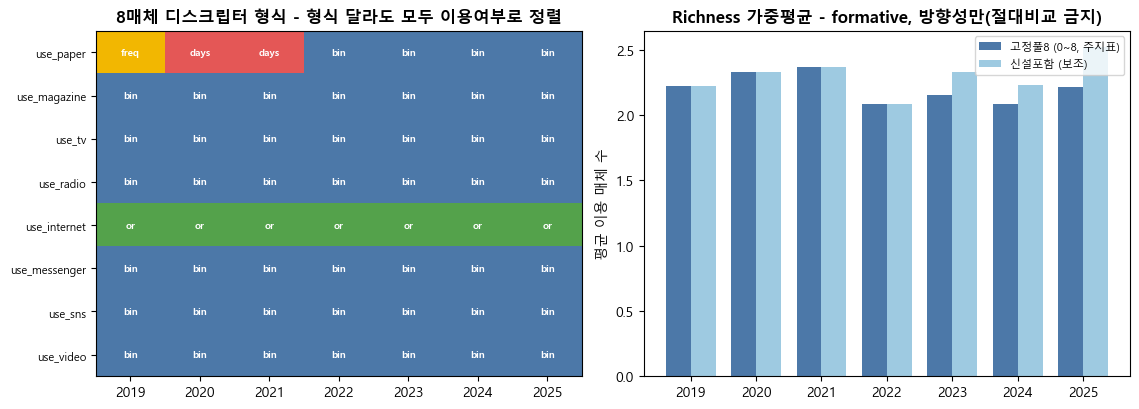

In [8]:
# [시각화 ③] (좌) 디스크립터 형식 지도 (우) 고정풀8 vs 신설포함 richness(가중, 방향성만)
kind_codes = {"bin": 0, "or": 1, "days": 2, "freq": 3}
M = np.array([[kind_codes[hz.USE_BATTERY[m][y][0]] for y in YEARS] for m in hz.USE_BATTERY])
meds = list(hz.USE_BATTERY)
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2))

cmap4 = ListedColormap(["#4C78A8", "#54A24B", "#E45756", "#F2B701"])
axes[0].imshow(M, cmap=cmap4, aspect="auto", vmin=0, vmax=3)
axes[0].set_xticks(range(len(YEARS))); axes[0].set_xticklabels([str(y) for y in YEARS])
axes[0].set_yticks(range(len(meds))); axes[0].set_yticklabels(meds, fontsize=8)
for r in range(len(meds)):
    for c in range(len(YEARS)):
        axes[0].text(c, r, hz.USE_BATTERY[meds[r]][YEARS[c]][0], ha="center", va="center",
                     fontsize=7, color="white", weight="bold")
axes[0].set_title("8매체 디스크립터 형식 - 형식 달라도 모두 이용여부로 정렬", weight="bold")

w = panel["wt_year_eq"]
r8 = [np.average(panel.loc[panel.year == y, "richness_fixed8"],
                 weights=panel.loc[panel.year == y, "wt_year_eq"]) for y in YEARS]
ri = [np.average(panel.loc[panel.year == y, "richness_incl"],
                 weights=panel.loc[panel.year == y, "wt_year_eq"]) for y in YEARS]
x = np.arange(len(YEARS)); bw = 0.38
axes[1].bar(x - bw/2, r8, bw, label="고정풀8 (0~8, 주지표)", color="#4C78A8")
axes[1].bar(x + bw/2, ri, bw, label="신설포함 (보조)", color="#9ecae1")
axes[1].set_xticks(x); axes[1].set_xticklabels([str(y) for y in YEARS])
axes[1].set_title("Richness 가중평균 - formative, 방향성만(절대비교 금지)", weight="bold")
axes[1].set_ylabel("평균 이용 매체 수"); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

> #### 🟩 Decision Box ② — 다양성 = **8매체 고정풀**(formative·방향성만)
>
> **결정**: 다양성 종단축은 7개년 공통 **8매체 고정풀**(`richness_fixed8`, 0~8)로 *구성을 고정*하고, **절대수준의 연도 비교는 하지 않는다**(방향성만). 신설 매체(숏폼·OTT·AI)는 고정풀 밖 보조(`richness_incl`)로 *신설 기여*만 가시화한다.
>
> **근거**: Richness는 매체 목록이 바뀌면 의미가 바뀌는 **formative 구성지표**다(반영이 아니라 구성). 신설 매체가 2023·2025에 도입되면 풀을 늘리는 순간 *측정 변화*가 *행동 변화*로 오인된다. 고정풀로 8매체에 못박아야 연도 간 **구성이 동일**해진다. 그래도 formative라 잠재평균 동등이 성립하지 않아 절대수준은 비교 불가 — 방향(추세 모양)만 읽는다.
>
> **대안 기각**: ① 매년 가용 매체 전부 합산 → 풀 크기 변동이 추세에 혼입(거짓 상승). ② 신설포함을 주지표로 → 2023 이전과 단절. 고정풀8 주 + 신설포함 보조가 종단 정합과 신설 가시화를 동시에 만족.

#### **[발견 ③] 8매체는 '형식이 달라도 이용여부로' 정렬되고, formative라 방향성만 본다**

매체 이용 문항은 56칸(8매체×7개년) 중 형식이 `bin` 46 · `or` 7(인터넷 전개년) · `days` 2 · `freq` 1로 섞여 있다 — 종이신문 하나만 봐도 `freq→days→bin`을 오간다. `harmonize.USE_BATTERY`의 디스크립터가 이 차이를 흡수해 **모두 '이용여부(>0)'로 이진 정렬**하고, 그 합이 `richness_fixed8`(0~8)다. 신설(숏폼·OTT·AI)은 2023·2025에야 등장해 부재연도가 많아 고정풀 밖 보조(`richness_incl`)로 둔다. ⚠️ 다양성은 **formative**(매체 목록이 지수를 구성)라, 위 가중평균(고정풀8 ≈2.1~2.4매체)은 *정렬이 합리적인지*를 보여줄 뿐 **연도 간 절대수준 비교의 근거가 아니다** — 신설포함과의 격차(2025 Δ가 가장 큼)도 *신설 기여의 가시화*일 뿐 추세 주장이 아니다(DB②). 다양성은 방향성만 본다.

→ **③ 다양성 정렬 — 완료(고정풀8·formative 확정). 다음은 정렬이 지수로 이어지는 경로.**

## 4. 정렬→지수 — 두 축의 해석 규칙은 왜 갈리나

§1~3에서 확정한 개념→변수 정렬이 `health_index_panel`(thin 어댑터)을 통해 **연도 지수**로 이어진다. 신뢰지수는 핵심3 pooled z평균→1~100 척도(reflective), 다양성지수는 `richness_fixed8`→1~100(formative), NCHI는 둘의 기하평균이다. 핵심은 **같은 NCHI 안에서도 두 축의 해석 규칙이 다르다**는 것 — 신뢰는 연도 절대수준 비교를 허용하고(측정불변 전제, 21·22), 다양성은 방향성만 본다(formative, DB②).

In [9]:
# 정렬->지수: 신뢰(연도 비교 가능) vs 다양성(방향성만) vs NCHI
trust = hip.trust_index_panel(panel)
div = hip.diversity_index_panel(panel)
nchi = hip.nchi_by_year(panel, diversity_version="fixed8")

print("[신뢰지수 — reflective, 연도 비교 가능]")
print(trust.round(2).to_string())
print(f"  -> 2019 {trust['trust_index'][2019]:.1f} -> 2025 {trust['trust_index'][2025]:.1f}"
      f" (Δ{trust['trust_index'][2025]-trust['trust_index'][2019]:+.1f}, 완만한 우상향; 03서 추세 본격분석)")
print("\n[다양성지수 — formative, 방향성만(절대비교 금지)]")
print(div.round(2).to_string())
print("\n[NCHI = sqrt(신뢰 x 다양성)]")
print(nchi.round(2).to_string())

[신뢰지수 — reflective, 연도 비교 가능]
      trust_index  n_valid
2019        51.29     5040
2020        56.61     5010
2021        58.01     5010
2022        55.68    58936
2023        55.16     5000
2024        54.84     6000
2025        60.10     6000
  -> 2019 51.3 -> 2025 60.1 (Δ+8.8, 완만한 우상향; 03서 추세 본격분석)

[다양성지수 — formative, 방향성만(절대비교 금지)]
      diversity_index_fixed8  diversity_index_incl  n_valid
2019                   28.46                 20.97     5040
2020                   29.83                 21.97     5010
2021                   30.26                 22.28     5010
2022                   26.81                 19.77    58936
2023                   27.66                 21.99     5000
2024                   26.78                 21.10     6000
2025                   28.45                 23.67     6000

[NCHI = sqrt(신뢰 x 다양성)]
      trust_index  diversity_index   nchi
2019        51.29            28.46  38.20
2020        56.61            29.83  41.09
2021        58.01            

**[시각화 ④] 정렬→지수** — 신뢰지수(실선, 연도 비교 가능)와 다양성지수(점선, 방향성만)를 한 축에 겹쳐, 같은 NCHI 입력이라도 해석 규칙이 왜 갈리는지 시각으로 새긴다.

C:\Users\kik32\AppData\Local\Temp\ipykernel_32640\1226890273.py:16: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Malgun Gothic.
  plt.tight_layout(); plt.show()
C:\Users\kik32\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


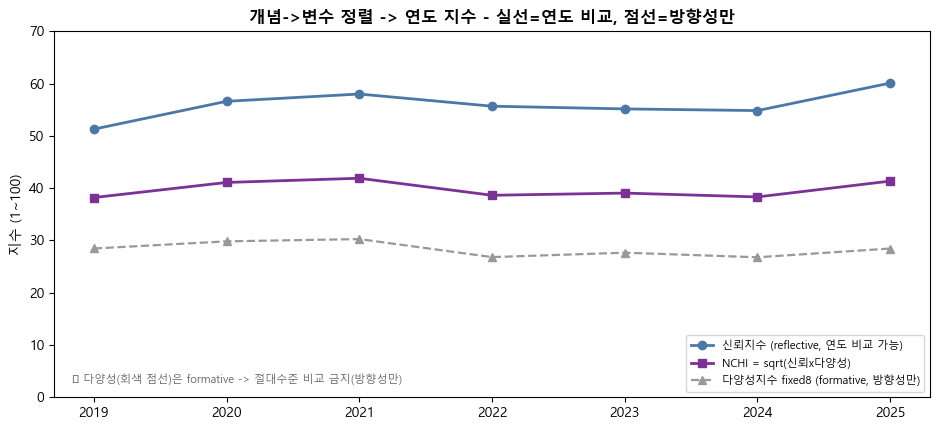

In [10]:
# [시각화 ④] 정렬->지수: 신뢰(연도 비교) 실선 vs 다양성(방향성만) 점선
fig, ax = plt.subplots(figsize=(9.5, 4.4))
xs = [str(y) for y in YEARS]
ax.plot(xs, [trust["trust_index"][y] for y in YEARS], "o-", color="#4C78A8", lw=2,
        label="신뢰지수 (reflective, 연도 비교 가능)")
ax.plot(xs, [nchi["nchi"][y] for y in YEARS], "s-", color="#7B3294", lw=2,
        label="NCHI = sqrt(신뢰x다양성)")
ax.plot(xs, [div["diversity_index_fixed8"][y] for y in YEARS], "^--", color="#999999", lw=1.6,
        label="다양성지수 fixed8 (formative, 방향성만)")
ax.set_ylim(0, 70)
ax.set_ylabel("지수 (1~100)")
ax.set_title("개념->변수 정렬 -> 연도 지수 - 실선=연도 비교, 점선=방향성만", weight="bold")
ax.legend(fontsize=8, loc="lower right")
ax.text(0.02, 0.04, "⚠ 다양성(회색 점선)은 formative -> 절대수준 비교 금지(방향성만)",
        transform=ax.transAxes, fontsize=8, color="#666")
plt.tight_layout(); plt.show()

#### **[발견 ④] 같은 NCHI 안에서도 신뢰는 '연도 비교', 다양성은 '방향성만'으로 갈린다**

개념→변수 정렬은 곧바로 지수로 이어진다. **신뢰지수**는 핵심3 reflective 합성이라 측정불변(21·22)을 전제로 **연도 절대수준 비교가 정당** — 2019 51.3에서 2025 60.1로 완만히 우상향한다(03에서 본격 추세 분석). **다양성지수**(fixed8)는 26.8~30.3 범위지만 formative라 *이 수치들의 연도 비교는 하지 않고* 방향만 본다(DB②). 둘의 기하평균인 **NCHI**(38~42)는 다양성의 formative 한계를 상속하므로 종단 해석은 방향성 위주다. 핵심은 **한 지수(NCHI) 안에서도 축마다 해석 규칙이 다르다**는 것 — 이 이원 규칙이 §1~3의 정렬에서 직접 도출된다. 시각화에서 신뢰·NCHI는 실선(비교 가능), 다양성은 회색 점선(방향성만)으로 구분했다.

→ **④ 정렬→지수 — 완료(이원 규칙 확정). 다음은 최종 매핑표.**

## 5. 최종 변수 매핑표 (SSOT 확정 — 7개년 패널 버전)

§1~4의 정렬을 한 장으로 확정한다. v1의 단년 매핑표를 **7개년 패널 기준**으로 갱신했다 — 각 개념이 어떤 7개년 변수군으로 정렬되고, 어떻게 처리되며, reflective/formative 중 무엇이라 어떤 해석 규칙을 받는지.

| 역할 | 개념(SSOT 키) | 7개년 변수 정렬 | 처리 | 성격·해석 규칙 |
|------|--------------|----------------|------|----------------|
| **신뢰 코어** | `CRED_FACTOR_CORE3` (공정·전문·정확) | `CRED_BATTERY` 형용사 매핑(번호 리셋 흡수); 7개년 전부 존재 | 1~5 유효→pooled z평균→1~100 | **reflective** · α=0.805 · **연도 비교 가능**(측정불변 21·22) |
| 신뢰 민감도 | `cred_trustworthy` | 2019~2022만 | 핵심3+1 민감도 | reflective · 부분연도(주모형 배제) |
| 신뢰 배제 | `press_free`·`media_influence` | 언론자유(7개년)·영향력(2021~) | 신뢰 합산 금지 | 별개 차원(r≈0.48~0.51) |
| **다양성 코어** | `FIXED_POOL8` → `richness_fixed8` | `USE_BATTERY` 8매체(freq/days/bin/or→이용여부); 7개년 공통 | 이진(>0) 합산(0~8)→1~100 | **formative** · **방향성만**(절대비교 금지, 06 R4) |
| 다양성 보조 | `richness_incl` | +숏폼·OTT·AI(2023·2025~) | 신설 기여 가시화 | formative · 부재연도=fixed8 |
| 집계 가중 | `wt_year_eq` | 연도기여 1/7 균등(2022 지배 보정) | 모든 연도 추정 | harmonize §6 |
| 인구 통제 | `sex`·`age`·`edu`·`income_band7`·`job`·`region` | `SRC` 매핑(연도별 재코딩) | crosswalk §3 | 세그먼트·통제 |

## 6. 종합 — 개념→변수 정렬 → 후속 매핑

이 노트북은 새 지수를 만들지 않는다. **해마다 흩어진 문항을 개념으로 정렬**해, 신뢰축(reflective·핵심3)과 다양성축(formative·고정풀8)이 7개년 한 자(尺)로 묶이는 근거를 입증하고, 그 정렬이 지수·해석 규칙으로 어떻게 이어지는지를 정의했다. 아래 매핑이 본 노트북의 산출물이며 self-check로 재현성을 봉인한다.

In [11]:
# 개념->변수 정렬 -> 후속 매핑 + self-check (재현성)
print("=" * 64)
print("02 개념->변수 정렬 — 발견 -> 후속 처리")
print("=" * 64)
mapping = [
    ("① 문항번호 리셋", "변수명 직결 불가(Q77->Q78->Q69->Q85)",
     "형용사 키로 정렬 = CRED_BATTERY (-> harmonize)"),
    ("② 신뢰 자격집합", "7개년 공통 긍정 valence = 공정/전문/정확",
     "핵심3 고정, trustworthy 민감도/influence 배제 (-> 21·22)"),
    ("③ 신뢰 reflective", "pooled a=0.805·상관 0.55~0.64",
     "연도 비교 허용(측정불변 검정으로 봉인 -> 21·22)"),
    ("④ 다양성 formative", "8매체 형식(freq/days/bin/or)->이용여부",
     "고정풀8 구성 고정·방향성만 (-> 03·DB②)"),
]
for f, prob, dec in mapping:
    print(f"\n{f}\n   발견: {prob}\n   결정: {dec}")

# self-check
a_core3 = nf.cronbach_alpha(panel[CORE3].apply(pd.to_numeric, errors="coerce"))
cc25 = int(panel.loc[panel.year == 2025, CORE3].notna().all(axis=1).sum())
assert len(CORE3) == 3 and CORE3 == ["cred_fair", "cred_professional", "cred_accurate"], "핵심3 스펙 이탈"
assert len(POOL8) == 8, "고정풀8 매체 수 이탈"
assert all(hz.CRED_BATTERY[i][y] is not None for i in CORE3 for y in YEARS), "핵심3 7개년 부재"
assert 0.78 <= a_core3 <= 0.83, f"pooled alpha 이탈: {a_core3:.3f}"
print("\n" + "-" * 64)
print(f"[self-check] 핵심3=3지표·7개년 전존재 · 고정풀8=8매체 · pooled a={a_core3:.3f} · 2025 완전케이스={cc25:,} — PASS")
print("⚠️ 산출 수치는 KPF 원자료 재검증·측정 비동등 검정 전 보고서/웹데모 직접 인용 신중(검증 게이트).")

02 개념->변수 정렬 — 발견 -> 후속 처리

① 문항번호 리셋
   발견: 변수명 직결 불가(Q77->Q78->Q69->Q85)
   결정: 형용사 키로 정렬 = CRED_BATTERY (-> harmonize)

② 신뢰 자격집합
   발견: 7개년 공통 긍정 valence = 공정/전문/정확
   결정: 핵심3 고정, trustworthy 민감도/influence 배제 (-> 21·22)

③ 신뢰 reflective
   발견: pooled a=0.805·상관 0.55~0.64
   결정: 연도 비교 허용(측정불변 검정으로 봉인 -> 21·22)

④ 다양성 formative
   발견: 8매체 형식(freq/days/bin/or)->이용여부
   결정: 고정풀8 구성 고정·방향성만 (-> 03·DB②)

----------------------------------------------------------------
[self-check] 핵심3=3지표·7개년 전존재 · 고정풀8=8매체 · pooled a=0.805 · 2025 완전케이스=6,000 — PASS
⚠️ 산출 수치는 KPF 원자료 재검증·측정 비동등 검정 전 보고서/웹데모 직접 인용 신중(검증 게이트).


### 종합
- **정렬 원리**: 신뢰성 문항번호는 해마다 리셋(`Q77→Q78→Q69→Q85`) → **형용사(개념)** 를 키로 한 `CRED_BATTERY`만이 7개년을 잇는다(변수명 직결 불가).
- **신뢰 자격집합**: 7개년 전부 존재 + 긍정 valence = **공정·전문·정확(핵심3)**. `trustworthy`(4개년)·`media_influence`(5개년)는 종단 주모형 배제(DB①).
- **신뢰 reflective**: pooled α=0.805·상관 0.55~0.64로 한 요인을 반영 → **연도 비교 허용**(측정불변은 21·22에서 봉인). `press_free`는 α 기여 0 → 별개 차원.
- **다양성 formative**: 8매체가 `freq/days/bin/or`로 흩어져도 `USE_BATTERY`가 *이용여부*로 정렬 → **고정풀8**로 구성 고정, **방향성만**(DB②). 신설은 보조(`richness_incl`).
- **이원 규칙**: 같은 NCHI 안에서도 신뢰=연도 비교 / 다양성=방향성만 — §1~3 정렬에서 직접 도출, 03·21·22 종단 해석의 토대.

### 한계 (v2 → 후속)
| 항목 | v2 처리 | 한계 | 후속 |
|------|--------|------|------|
| 신뢰 등가 | reflective·α로 필요조건 확인 | 측정불변 미검정(α는 충분조건 아님) | MGCFA 21·22(metric/scalar) |
| 다양성 | 고정풀8 formative→방향성만 | 잠재평균 동등 불성립(절대비교 불가) | scalar 불변 미검정 → 보류 |
| 2022 지배 | wt_year_eq 균등화 인용 | 본 노트북서 표본구조 미재현 | 01·11에서 입증 |

### 다음
- **21-mgcfa-invariance / 22-mgcfa-semopy-crossval**: 핵심3 신뢰요인의 **측정불변**(configural→metric→scalar)을 검정해 "연도 비교 가능"을 봉인.
- **03-health-index**: 본 노트북의 정렬·이원 규칙 위에서 신뢰·다양성·NCHI 7개년 추세를 지수화.

> ⚠️ 본 노트북은 **개념→변수 정렬(P3)** 이다 — 산출 수치는 KPF 원자료 재검증 **전 셀 일치**([kpf-revalidation](../docs/design/kpf-revalidation.md), 2026-07-11 · 입증 노트북 `12`)와 측정동등 검정(`21`~`23`) 통과로 인용 자격이 확정됐다 — 자격등급은 [p6-pdf-structure §3](../docs/report/p6-pdf-structure.md). 다양성은 formative 한계 → 방향성만(06 §결과 R4).